# Checkpointing and Transfer Learning

### Welcome to the 7th Lab of 42028: Deep Learning and CNN!

In this  Lab/Tutorial session you will be learning how to checkpoint a model and also restart training from an existing checkpoint. In the second session you will implement Transfer learning/fine-tuning.

Designing of AlexNet architecture will also be discussed.

So lets get started!

## Tutorial:
1. Checkpointing or saving trained model
2. Transfer learning
3. Classic CNNs

## Tasks for this week:

1. Implementation of CNN for Dogs and Cats classification using Keras API. 
2. Save the snapshot of trained model using checkpoint
3. Loading the weights of trained model and start training again.
3. Using out-of-the-box models for classification
4. Transfer learning/fine-tuning from already trained model
5. Implement AlexNet.


## Task-1: Implementing CNN for Dogs and Cats classification using Keras API

### Step 1: Import required packages

we will need tensorflow, numpy, os and keras


In [1]:
#Check GPU

!nvidia-smi

Sat Mar 28 01:48:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   25C    P8             10W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Fix for GPU Compilation Error (libdevice not found)

**What this does:** This sets a system environment variable (`XLA_FLAGS`) to explicitly tell TensorFlow's XLA compiler the correct base directory (`/opt/conda`) to search for CUDA libraries.

**Why it is needed:**
To train efficiently on a GPU, TensorFlow uses an optimizing compiler called XLA. XLA requires a specific CUDA file named `libdevice.10.bc` to compile the graph. In many custom or cloud-based Conda environments, this file is located outside of TensorFlow's default search paths, which causes `model.fit()` to crash with an `InternalError`. By manually pointing to the correct directory, we prevent the crash and enable hardware acceleration.

In [2]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc
/opt/conda/nvvm/libdevice/libdevice.10.bc


In [3]:
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'

In [4]:
!pwd

/home/sagemaker-user/42028/Week7


In [5]:
!mkdir weights

In [6]:
!mkdir dataset

In [7]:
import os
import tensorflow as tf
import zipfile
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import LabelBinarizer
from keras.callbacks import ModelCheckpoint
from keras.optimizers import SGD
from keras.datasets import cifar10
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2026-03-28 01:49:50.458663: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 01:49:50.640271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774662590.666258     410 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774662590.676627     410 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-28 01:49:50.877459: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Step 2: Download the Cats & Dogs dataset

In [9]:
!wget --no-check-certificate \
    https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip \
    -O /tmp/cats_and_dogs_filtered.zip

--2026-03-28 01:51:55--  https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.195.155, 172.217.25.219, 142.251.42.123, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.195.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M  20.0MB/s    in 4.7s    

2026-03-28 01:52:00 (13.9 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [10]:
local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'cats')

# Directory with our training dog pictures
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')

# Directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

### Step 3:  Design the CNN Architecture 

Design the following CNN architecture:


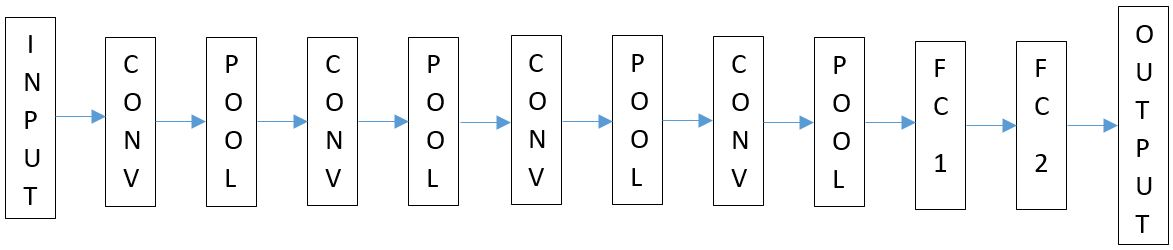


Input: $150 X 150 X 3$ image

No. of filters:
- Conv1 : 32, 3x3
- Conv2 : 64, 3x3
- Conv4 : 128, 3x3
- Conv4 : 128, 3x3

Activation function in CONV layer: Relu

Pool: MaxPooling, 2x2

FC Layer: 512 nodes, Activation : ReLu

Activation function in Output layer : sigmoid, 

**Hint:** Use Conv2D(), MaxPooling2D(), Flatten(), and Dense()

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774662831.692062     410 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13764 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


### Step 4. Model Compilation

In [12]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])

### Step 5. Using Image generator to load images and generate labels automatically. Image generator also resizes the images.

In [13]:
# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Task-2: Saving the snapshot of model as checkpoint



### Step 6: Checkpointing

In [15]:
#checkpoint = ModelCheckpoint('weights.{epoch:02d}-{val_loss:.2f}.hdf5', monitor='val_loss', save_best_only=True, verbose=1, save_freq='epoch')
filepath = './weights/weights.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

### Step 7. Training the model

In [16]:
history = model.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=10,
      validation_data=validation_generator,
      validation_steps=10,  # 1000 images = batch_size * steps
      callbacks = [checkpoint],
      verbose=2)

Epoch 1/10


I0000 00:00:1774662952.024837    1483 service.cc:148] XLA service 0x7fd948008e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774662952.024868    1483 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-28 01:55:52.142343: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774662952.376447    1483 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-28 01:55:52.985359: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"

100/100 - 8s - 83ms/step - acc: 0.5250 - loss: 0.6908 - val_acc: 0.6650 - val_loss: 0.6799
Epoch 2/10
100/100 - 3s - 32ms/step - acc: 0.5970 - loss: 0.6727 - val_acc: 0.6450 - val_loss: 0.6476
Epoch 3/10
100/100 - 3s - 31ms/step - acc: 0.6130 - loss: 0.6510 - val_acc: 0.6200 - val_loss: 0.6347
Epoch 4/10
100/100 - 3s - 30ms/step - acc: 0.6630 - loss: 0.6213 - val_acc: 0.6250 - val_loss: 0.6522
Epoch 5/10
100/100 - 3s - 31ms/step - acc: 0.6830 - loss: 0.5894 - val_acc: 0.6750 - val_loss: 0.6022
Epoch 6/10
100/100 - 3s - 31ms/step - acc: 0.7010 - loss: 0.5674 - val_acc: 0.7400 - val_loss: 0.5724
Epoch 7/10
100/100 - 3s - 30ms/step - acc: 0.7355 - loss: 0.5439 - val_acc: 0.6150 - val_loss: 0.6188
Epoch 8/10
100/100 - 3s - 30ms/step - acc: 0.7360 - loss: 0.5301 - val_acc: 0.6800 - val_loss: 0.5644
Epoch 9/10
100/100 - 3s - 30ms/step - acc: 0.7585 - loss: 0.5045 - val_acc: 0.7000 - val_loss: 0.5709
Epoch 10/10
100/100 - 3s - 30ms/step - acc: 0.7540 - loss: 0.4944 - val_acc: 0.7200 - val_los

## Task 3: Loading the weights of trained model and start training again.

### Step 8.  Retraining from saved model

In [17]:
!ls ./weights/

weights.01-0.68.keras  weights.05-0.60.keras  weights.09-0.57.keras
weights.02-0.65.keras  weights.06-0.57.keras  weights.10-0.54.keras
weights.03-0.63.keras  weights.07-0.62.keras
weights.04-0.65.keras  weights.08-0.56.keras


In [19]:
## Go to the /tmp folder and copy the name of the last saved model
model_modify=tf.keras.models.load_model('./weights/weights.10-0.54.keras')

### Step 9. Compile the modified model 

In [21]:
model_modify.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])
model_modify.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [23]:
filepath = './weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

In [24]:
# Train the model
history = model_modify.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=10,
      validation_data=validation_generator,
      validation_steps=10,  # 1000 images = batch_size * steps
      callbacks = [checkpoint],
      verbose=2)

Epoch 1/10
100/100 - 5s - 52ms/step - acc: 0.7620 - loss: 0.4822 - val_acc: 0.7450 - val_loss: 0.5118
Epoch 2/10
100/100 - 3s - 30ms/step - acc: 0.8015 - loss: 0.4435 - val_acc: 0.7600 - val_loss: 0.5241
Epoch 3/10
100/100 - 3s - 30ms/step - acc: 0.8060 - loss: 0.4316 - val_acc: 0.7550 - val_loss: 0.4779
Epoch 4/10
100/100 - 3s - 30ms/step - acc: 0.8015 - loss: 0.4174 - val_acc: 0.6800 - val_loss: 0.5955
Epoch 5/10
100/100 - 3s - 30ms/step - acc: 0.8165 - loss: 0.4009 - val_acc: 0.7100 - val_loss: 0.6074
Epoch 6/10
100/100 - 3s - 30ms/step - acc: 0.8205 - loss: 0.3818 - val_acc: 0.7400 - val_loss: 0.5278
Epoch 7/10
100/100 - 3s - 30ms/step - acc: 0.8395 - loss: 0.3662 - val_acc: 0.6900 - val_loss: 0.6113
Epoch 8/10
100/100 - 3s - 29ms/step - acc: 0.8470 - loss: 0.3466 - val_acc: 0.7250 - val_loss: 0.5662
Epoch 9/10
100/100 - 3s - 30ms/step - acc: 0.8645 - loss: 0.3279 - val_acc: 0.7350 - val_loss: 0.5576
Epoch 10/10
100/100 - 3s - 29ms/step - acc: 0.8740 - loss: 0.3102 - val_acc: 0.720

In [25]:
!ls ./weights/

weights.01-0.68.keras  weights_modified.01-0.51.keras
weights.02-0.65.keras  weights_modified.02-0.52.keras
weights.03-0.63.keras  weights_modified.03-0.48.keras
weights.04-0.65.keras  weights_modified.04-0.60.keras
weights.05-0.60.keras  weights_modified.05-0.61.keras
weights.06-0.57.keras  weights_modified.06-0.53.keras
weights.07-0.62.keras  weights_modified.07-0.61.keras
weights.08-0.56.keras  weights_modified.08-0.57.keras
weights.09-0.57.keras  weights_modified.09-0.56.keras
weights.10-0.54.keras  weights_modified.10-0.58.keras


## Task 4: Transfer Learning - Using out-of-the-box models for classification

### Step 1: Unzip dataset (images.zip) for testing

[How to use pretrained networks for out of the box classification](https://keras.io/applications/)

In [26]:
!unzip images.zip

Archive:  images.zip
  inflating: images/cat.0.jpg        
  inflating: images/cat.jpg          
  inflating: images/dog.10.jpg       


### Step 2. Using ResNet50 pretrained model for classification 

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


2026-03-28 02:01:22.021441: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-28 02:01:22.181931: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,256,14,14]{3,2,1,0}, f32[256,256,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasAct

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
Predicted: [('n04493381', 'tub', 0.06386345), ('n02123597', 'Siamese_cat', 0.058763642), ('n02124075', 'Egyptian_cat', 0.04921693)]


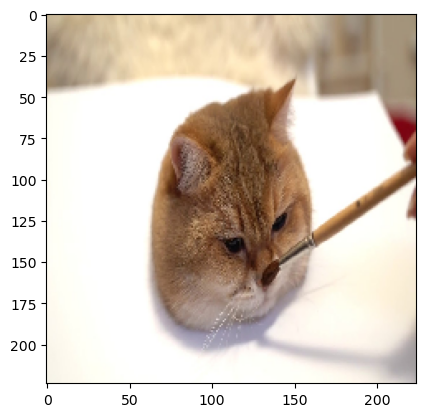

In [27]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt

# Load the ResNet50 model with pretrained weights
model = ResNet50(weights='imagenet')

img_path = './images/cat.jpg'
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

features = model.predict(x)
preds = model.predict(x)
print('Predicted:', decode_predictions(preds, top=3)[0])

### Step 3: Transfer learning

We will use the VGG16 CNN architecture as the base model and adapt/re-train the FC layers to Dogs and Cats classification task.

VGG16 CNN architecture is given below:

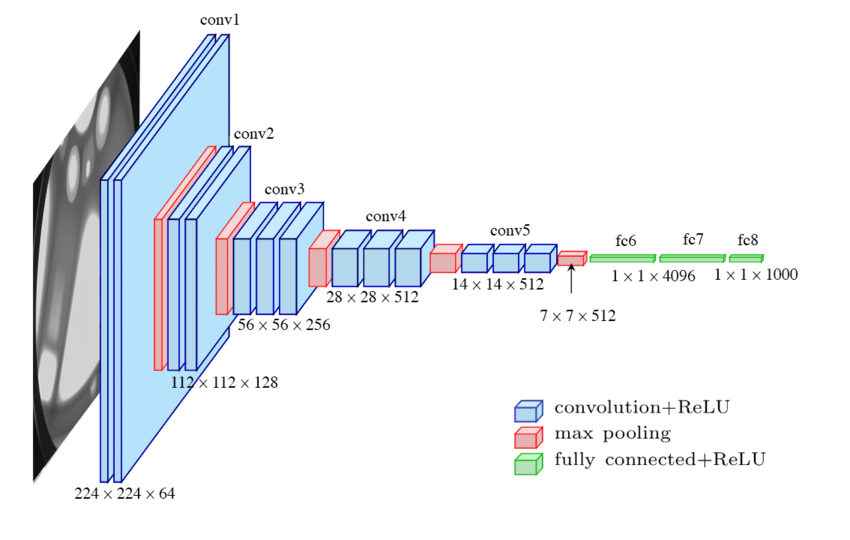

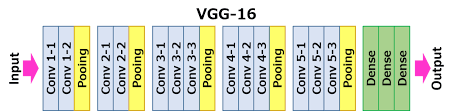

In [28]:
from tensorflow.keras.applications import VGG16
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(150, 150, 3))


from keras import models
from keras import layers
from keras import optimizers

# Load the CONV layers of VGG16 model and add the FC layers

model = models.Sequential()
model.add(conv_base)
#model.pop()
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
conv_base.summary()
#conv_base.layers.pop()
#conv_base.layers.pop()
#conv_base.layers.pop()
for layer in conv_base.layers[:-4]:
    layer.trainable = False
 
# Check the trainable status of the individual layers
for layer in conv_base.layers:
    print(layer, layer.trainable)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

<InputLayer name=input_layer_2, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> True
<Conv2D name=block5_conv2, built=True> True
<Conv2D name=block5_conv3, built=True> True
<MaxPooling2D name=block5_pool, built=True> True


In [31]:
#model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### Step 4:  Training CNN with ImageDataGenerator

In [32]:
# Updated to do image augmentation
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [33]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

In [35]:
# Train the model
history = model.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=10,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Epoch 1/10


2026-03-28 02:02:14.522916: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,64,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-28 02:02:14.618274: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,64,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,64,150,150]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasAct

100/100 - 22s - 221ms/step - acc: 0.7625 - loss: 0.4905 - val_acc: 0.9030 - val_loss: 0.2549
Epoch 2/10
100/100 - 15s - 148ms/step - acc: 0.8590 - loss: 0.3247 - val_acc: 0.9210 - val_loss: 0.2057
Epoch 3/10
100/100 - 15s - 147ms/step - acc: 0.8825 - loss: 0.2944 - val_acc: 0.9200 - val_loss: 0.2072
Epoch 4/10
100/100 - 15s - 148ms/step - acc: 0.8970 - loss: 0.2429 - val_acc: 0.9120 - val_loss: 0.2129
Epoch 5/10
100/100 - 15s - 147ms/step - acc: 0.9150 - loss: 0.2084 - val_acc: 0.9170 - val_loss: 0.2611
Epoch 6/10
100/100 - 15s - 147ms/step - acc: 0.9165 - loss: 0.2123 - val_acc: 0.9400 - val_loss: 0.1629
Epoch 7/10
100/100 - 15s - 148ms/step - acc: 0.9330 - loss: 0.1884 - val_acc: 0.9250 - val_loss: 0.2144
Epoch 8/10
100/100 - 15s - 148ms/step - acc: 0.9300 - loss: 0.1770 - val_acc: 0.9420 - val_loss: 0.1791
Epoch 9/10
100/100 - 15s - 149ms/step - acc: 0.9320 - loss: 0.1803 - val_acc: 0.9300 - val_loss: 0.2107
Epoch 10/10
100/100 - 15s - 148ms/step - acc: 0.9430 - loss: 0.1511 - val_a

### Step 5:  Visualization of results 

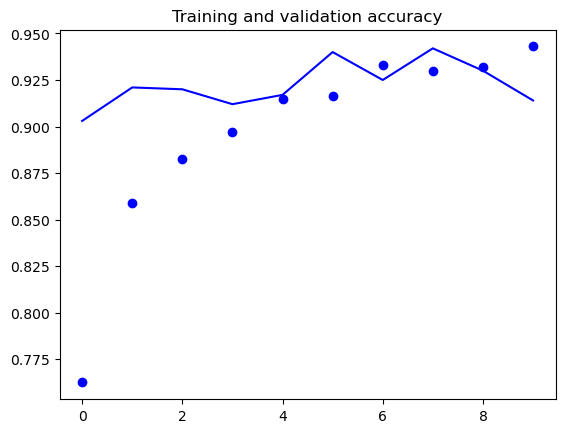

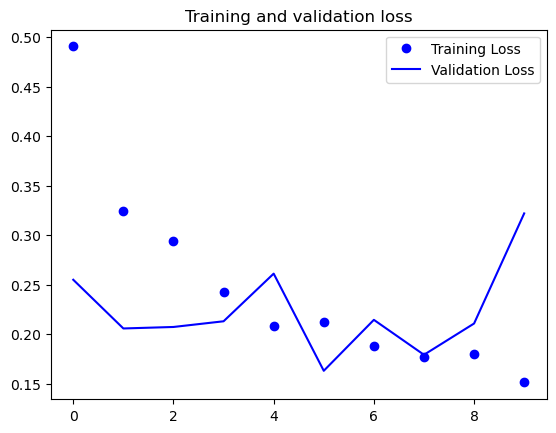

In [36]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## Task 5: AlexNet implementation

The Alexnet CNN architecture is show in the diagram given below:

<!-- ![alt text](https://www.oreilly.com/api/v2/epubs/9781491980446/files/assets/tfdl_0106.png) -->
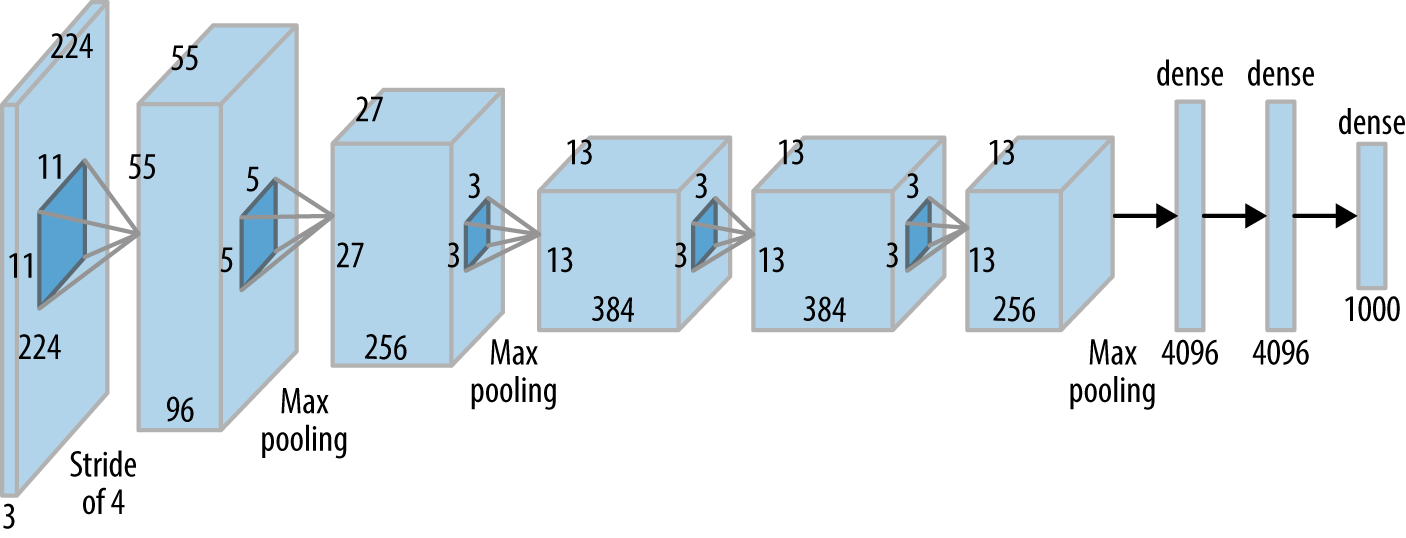

### Create the Alexnet architecture

In [37]:
model = tf.keras.models.Sequential([
    #Conv_1          #original model was built for input shape of 224X224
    tf.keras.layers.Conv2D(96, (11,11),strides=4, padding='valid', activation='relu', input_shape=(224, 224, 3)),
    # Pooling_1
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2,2),padding='valid'),
    # Batch Normalisation_1
    tf.keras.layers.BatchNormalization(),
    # Conv_2
    tf.keras.layers.Conv2D(256, (5,5),strides=1, padding='valid', activation='relu'),
    # Pooling_2
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2,2),padding='valid'),
    #Batch Normalisation_2
    tf.keras.layers.BatchNormalization(),
    # Conv_3
    tf.keras.layers.Conv2D(384, (3,3),strides=1, padding='valid', activation='relu'),
    # Batch Normalisation_3
    tf.keras.layers.BatchNormalization(),
    # Conv_4
    tf.keras.layers.Conv2D(384, (3,3),strides=1, padding='valid', activation='relu'),
    # Batch Normalisation_3
    tf.keras.layers.BatchNormalization(),
    #conv_5
    tf.keras.layers.Conv2D(256, (3,3),strides=1, padding='valid', activation='relu'),
    #pooling_3
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2,2),padding='valid'),
    #Batch Normalization_4
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    #Dense layer_1
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    #Dense layer_2
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    #Dense layer_3
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])


### Create the dataset by resizing the images to 224X224 for training Alexnet.

In [38]:
# Updated to do image augmentation
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(224, 224),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(224, 224),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [39]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])

In [40]:
# Train the model
history = model.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=20,
      validation_data=validation_generator,
      validation_steps=10,  # 1000 images = batch_size * steps
      #callbacks = [checkpoint],
      verbose=2)

Epoch 1/20


2026-03-28 02:06:27.033147: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,256,23,23]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,96,27,27]{3,2,1,0}, f32[256,96,5,5]{3,2,1,0}, f32[256]{0}), window={size=5x5}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-28 02:06:27.271469: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,384,9,9]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,256,11,11]{3,2,1,0}, f32[384,256,3,3]{3,2,1,0}, f32[384]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

100/100 - 33s - 331ms/step - acc: 0.5375 - loss: 0.8812 - val_acc: 0.4700 - val_loss: 0.8130
Epoch 2/20
100/100 - 34s - 338ms/step - acc: 0.5420 - loss: 0.8514 - val_acc: 0.5100 - val_loss: 0.7417
Epoch 3/20
100/100 - 23s - 230ms/step - acc: 0.5455 - loss: 0.8783 - val_acc: 0.5000 - val_loss: 0.9583
Epoch 4/20
100/100 - 23s - 230ms/step - acc: 0.5570 - loss: 0.8541 - val_acc: 0.5450 - val_loss: 0.7529
Epoch 5/20
100/100 - 23s - 231ms/step - acc: 0.5610 - loss: 0.8517 - val_acc: 0.6000 - val_loss: 0.7718
Epoch 6/20
100/100 - 41s - 415ms/step - acc: 0.5785 - loss: 0.8144 - val_acc: 0.5650 - val_loss: 1.3731
Epoch 7/20
100/100 - 23s - 234ms/step - acc: 0.5650 - loss: 0.8442 - val_acc: 0.5400 - val_loss: 1.2973
Epoch 8/20
100/100 - 23s - 235ms/step - acc: 0.5365 - loss: 0.8658 - val_acc: 0.6200 - val_loss: 0.7504
Epoch 9/20
100/100 - 23s - 232ms/step - acc: 0.5565 - loss: 0.8335 - val_acc: 0.5400 - val_loss: 0.7550
Epoch 10/20
100/100 - 23s - 235ms/step - acc: 0.5555 - loss: 0.8241 - val_a

### Visualization of results


This is just for illustration only. The actual accuracy may vary based on the number of epochs

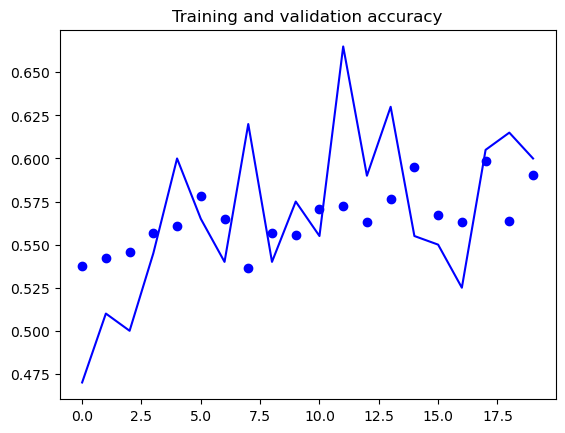

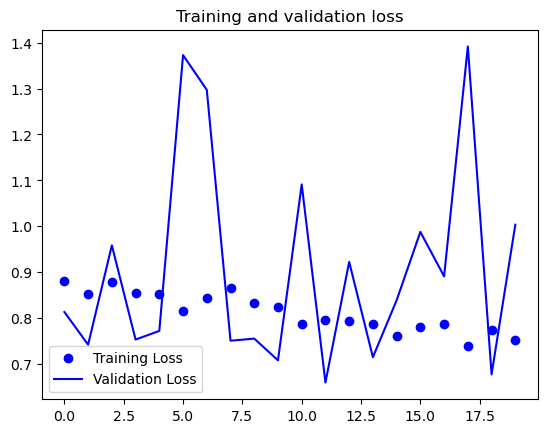

In [41]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()